**Đọc file dataset**  https://www.kaggle.com/datasets/shivamb/go-emotions-google-emotions-dataset/data

In [1]:
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

file_path = "go_emotions_dataset.csv"


df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shivamb/go-emotions-google-emotions-dataset",
    file_path
)

# Khai báo cấu trúc hệ thống phân loại 28 nhãn chuẩn của Google
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]



/tmp/ipykernel_4055/2057014050.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'go-emotions-google-emotions-dataset' dataset.


**Gom cụm các rater** nếu > 2 người cùng đánh giá 1 câu cùng 1 loại cảm xúc thì giữ, còn lại bỏ

In [2]:
# Gom cụm các rater đánh giá cùng một câu bình luận lại với nhau
grouped = df.groupby(['id', 'text'])[emotion_labels].sum().reset_index()
print(f"Số lượng câu bình luận độc nhất sau khi gom cụm: {len(grouped)} câu.")

# Nhãn cảm xúc nào được ít nhất 2 chuyên gia chọn mới tính là 1, dưới 2 phiếu bầu sẽ bị hủy (= 0)
for col in emotion_labels:
    grouped[col] = (grouped[col] >= 2).astype(int)

# Tính tổng số nhãn được kích hoạt cho mỗi câu
grouped['has_label'] = grouped[emotion_labels].sum(axis=1)
# Chỉ giữ lại các câu có ít nhất 1 nhãn cảm xúc đạt sự đồng thuận từ 2 người trở lên
grouped_clean = grouped[grouped['has_label'] > 0].drop(columns=['has_label'])

print(f"🔹 Số lượng câu bình luận sạch thu được: {len(grouped_clean)} câu.")

# Xem thử 3 dòng đầu tiên sau khi làm sạch
grouped_clean.head(3)

Số lượng câu bình luận độc nhất sau khi gom cụm: 58011 câu.
🔹 Số lượng câu bình luận sạch thu được: 54263 câu.


,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,Fast as [NAME] will carry me. Seriously uptown...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,You blew it. They played you like a fiddle.,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Làm sạch dữ liệu**

In [3]:
import nltk
from nltk.stem import WordNetLemmatizer
import re
import unicodedata

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def advanced_clean_text(text):
    # 1. Tránh lỗi crash nếu dữ liệu bị trống (NaN)
    if not isinstance(text, str):
        return ""

    # 2. Đưa về chữ thường
    text = text.lower()

    # Bước A: Đồng bộ hóa mọi loại "dấu nháy"
    text = re.sub(r"[’‘`´]", "'", text)

    # Bước B: Xử lý chữ cái có dấu
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # 3. Khai triển từ viết tắt
    text = re.sub(r"i'm", "i am", text)
    text = re.sub(r"don't", "do not", text)
    text = re.sub(r"doesn't", "does not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"isn't", "is not", text)
    text = re.sub(r"aren't", "are not", text)
    text = re.sub(r"haven't", "have not", text)
    text = re.sub(r"hasn't", "has not", text)
    text = re.sub(r"didn't", "did not", text)
    text = re.sub(r"it's", "it is", text)
    text = re.sub(r"that's", "that is", text)
    text = re.sub(r"you're", "you are", text)
    text = re.sub(r"i've", "i have", text)
    text = re.sub(r"i'll", "i will", text)

    # Vớt những cụm viết tắt đuôi còn sót
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # KỸ THUẬT NỐI TỪ PHỦ ĐỊNH
    text = re.sub(r"\bnot\s+([a-z]+)\b", r"not_\1", text)

    # 4. Lọc ký tự đặc biệt (giữ lại khoảng trắng, a-z, 0-9 và dấu biểu cảm ! ? _)
    text = re.sub(r"[^a-z0-9\s\!\?\_]", " ", text)

    # 5. Ép các ký tự lặp lại vô nghĩa (soooo -> so)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 6. Gom khoảng trắng thừa và cắt tỉa
    text = re.sub(r"\s+", " ", text).strip()

    # 7. KỸ THUẬT LEMMATIZATION (Ép gốc từ)
    words = text.split()
    # pos='v' giúp ép các động từ (loved, loving, loves) về nguyên thể (love)
    lemmatized_words = [lemmatizer.lemmatize(w, pos='v') for w in words]
    text = " ".join(lemmatized_words)

    return text

# Chạy làm sạch trên tập dữ liệu
grouped_clean = grouped_clean.copy()
grouped_clean = grouped_clean.dropna(subset=['text'])
grouped_clean['text'] = grouped_clean['text'].apply(advanced_clean_text)
grouped_clean = grouped_clean[grouped_clean['text'] != ""]

grouped_clean.head(3)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,fast as name will carry me seriously uptown to...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,you blow it they play you like a fiddle,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,tl dr no more superbowls for name get ready fo...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Chia tập train test valid**

In [4]:
from sklearn.model_selection import train_test_split

# 1. Tách ma trận đầu vào X (văn bản sạch) và ma trận đầu ra Y (28 nhãn cảm xúc)
X_text = grouped_clean['text'].astype(str).values
Y_matrix = grouped_clean[emotion_labels].values

# 2. Lần tách thứ nhất: Giữ lại 80% cho tập Train, đẩy 20% còn lại vào tập tạm (Temp)
X_train_text, X_temp_text, Y_train, Y_temp = train_test_split(
    X_text, Y_matrix, test_size=0.20, random_state=42
)

# 3. Lần tách thứ hai: Chia đôi 50/50 tập tạm (Temp) để lấy ra đúng 10% Dev và 10% Test biệt lập
X_val_text, X_test_text, Y_val, Y_test = train_test_split(
    X_temp_text, Y_temp, test_size=0.50, random_state=42
)

print(f"Tập Huấn luyện (Train - 80%): {X_train_text.shape[0]} câu.")
print(f"Tập Phát triển/Kiểm định (Val - 10%): {X_val_text.shape[0]} câu.")
print(f"Tập Kiểm thử (Test - 10%): {X_test_text.shape[0]} câu.")
print(f"Tổng cộng: {X_train_text.shape[0] + X_val_text.shape[0] + X_test_text.shape[0]} câu.")

Tập Huấn luyện (Train - 80%): 43408 câu.
Tập Phát triển/Kiểm định (Val - 10%): 5426 câu.
Tập Kiểm thử (Test - 10%): 5426 câu.
Tổng cộng: 54260 câu.


**TRÍCH XUẤT TF-IDF VECTORIZER**

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

print("SỐ HÓA VĂN BẢN BẰNG BỘ TRÍCH XUẤT TF-IDF VECTORIZER (BẢN NÂNG CẤP MAX/MIN DF)...")

# 1. Lấy danh sách stop_words mặc định và bảo vệ các từ phủ định
custom_stop_words = list(ENGLISH_STOP_WORDS)
words_to_keep = ['not', 'no', 'nor', 'none', 'cannot', 'nothing']

for w in words_to_keep:
    if w in custom_stop_words:
        custom_stop_words.remove(w)

# 2. Khởi tạo TF-IDF với BỘ LỌC ĐÁY và TRẦN
tfidf = TfidfVectorizer(
    max_features= 5000,
    stop_words=custom_stop_words,
    ngram_range=(1, 2),
    min_df=5,       # Bỏ qua các từ xuất hiện dưới 5 lần
    max_df=0.85     # Bỏ qua các từ xuất hiện ở nhiều hơn 85% số câu
)

# 3. Tiến hành fit và transform trên tập Train
X_train_tfidf = tfidf.fit_transform(X_train_text)

# Chỉ transform (không fit lại) trên tập Val và Test
X_temp_tfidf = tfidf.transform(X_temp_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"Kích thước ma trận TF-IDF tập Train: {X_train_tfidf.shape}")

SỐ HÓA VĂN BẢN BẰNG BỘ TRÍCH XUẤT TF-IDF VECTORIZER (BẢN NÂNG CẤP MAX/MIN DF)...
Kích thước ma trận TF-IDF tập Train: (43408, 5000)


In [6]:
from google.colab import files

# 1. Lấy danh sách toàn bộ từ vựng đã học từ TF-IDF
learned_words = tfidf.get_feature_names_out()

file_name = "Danh_sach_tu_vung_TFIDF.txt"

# 2. Ghi dữ liệu ra file text
with open(file_name, "w", encoding="utf-8") as f:
    for word in learned_words:
        f.write(word + "\n")

print(f"✅ Đã đóng gói thành công {len(learned_words)} từ ra file '{file_name}'!")

# 3. LỆNH THẦN THÁNH: Kích hoạt tải thẳng file xuống máy tính cá nhân
files.download(file_name)

✅ Đã đóng gói thành công 5000 từ ra file 'Danh_sach_tu_vung_TFIDF.txt'!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score

# C nhỏ (<1): Mô hình rụt rè, mở rộng ranh giới (chống Overfit tốt cho TF-IDF)
# C lớn (>1): Mô hình khắt khe, bám sát dữ liệu Train (dễ Overfit)
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

best_c = 1.0
best_macro_f1 = 0.0
best_model = None

print("🎯 ĐANG TÌM KIẾM SIÊU THAM SỐ C TỐI ƯU CHO LINEAR SVC...")
print("=" * 65)

for c in C_values:
    print(f"🔄 Đang huấn luyện thử nghiệm với C = {c} ...")

    # 1. Khởi tạo mô hình với giá trị C hiện tại
    temp_classifier = OneVsRestClassifier(LinearSVC(C=c, class_weight='balanced', random_state=42))

    # 2. Huấn luyện trên tập Train
    temp_classifier.fit(X_train_tfidf, Y_train)

    # 3. Dự đoán trên tập Val (tạm thời dùng ngưỡng 0.0 mặc định để so sánh)
    Y_val_pred = temp_classifier.predict(X_val_tfidf)

    # 4. Tính toán điểm F1
    macro_f1 = f1_score(Y_val, Y_val_pred, average='macro', zero_division=0)
    micro_f1 = f1_score(Y_val, Y_val_pred, average='micro', zero_division=0)

    print(f"   => Hoàn thành! Macro F1: {macro_f1:.4f} | Micro F1: {micro_f1:.4f}\n")

    # 5. So sánh và lưu lại mô hình tốt nhất
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_c = c
        best_model = temp_classifier

print("=" * 65)
print(f"🏆 KẾT QUẢ: Giá trị C tối ưu nhất tìm được là C = {best_c}")
print(f"   Mức F1-Score (Macro) tốt nhất trên tập Val: {best_macro_f1:.4f}")

ovr_classifier = best_model

🎯 ĐANG TÌM KIẾM SIÊU THAM SỐ C TỐI ƯU CHO LINEAR SVC...
🔄 Đang huấn luyện thử nghiệm với C = 0.01 ...
   => Hoàn thành! Macro F1: 0.3628 | Micro F1: 0.4072

🔄 Đang huấn luyện thử nghiệm với C = 0.05 ...
   => Hoàn thành! Macro F1: 0.3465 | Micro F1: 0.3986

🔄 Đang huấn luyện thử nghiệm với C = 0.1 ...
   => Hoàn thành! Macro F1: 0.3404 | Micro F1: 0.3928

🔄 Đang huấn luyện thử nghiệm với C = 0.5 ...
   => Hoàn thành! Macro F1: 0.3207 | Micro F1: 0.3787

🔄 Đang huấn luyện thử nghiệm với C = 1.0 ...
   => Hoàn thành! Macro F1: 0.3125 | Micro F1: 0.3741

🔄 Đang huấn luyện thử nghiệm với C = 5.0 ...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


   => Hoàn thành! Macro F1: 0.2941 | Micro F1: 0.3594

🏆 KẾT QUẢ: Giá trị C tối ưu nhất tìm được là C = 0.01
   Mức F1-Score (Macro) tốt nhất trên tập Val: 0.3628


**Đánh giá trên tập test**

In [8]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

print("🎯 Đang dò tìm Ngưỡng Khoảng Cách (Distance Threshold) tối ưu...")

Y_val_decision_list = [estimator.decision_function(X_val_tfidf) for estimator in ovr_classifier.estimators_]
Y_val_decision = np.column_stack(Y_val_decision_list)

best_thresholds = []

for i in range(len(emotion_labels)):
    # Mặc định của SVM ranh giới là 0.0 (Lớn hơn 0 là CÓ, nhỏ hơn 0 là KHÔNG)
    best_t = 0.0
    best_f1 = 0.0

    # Xê dịch ranh giới từ -1.0 đến +1.0 với bước nhảy 0.05
    for t in np.arange(-1.0, 1.05, 0.05):
        preds = (Y_val_decision[:, i] >= t).astype(int)
        f1 = f1_score(Y_val[:, i], preds, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds.append(best_t)

# HIỂN THỊ DANH SÁCH NGƯỠNG TỐI ƯU ĐÃ TÌM ĐƯỢc
print("\n🌟 DANH SÁCH NGƯỠNG TỐI ƯU (BEST THRESHOLDS) CHO CÁC NHÃN:")
print("-" * 70)

for i in range(len(emotion_labels)):
    label = emotion_labels[i].upper()
    thresh = best_thresholds[i]

    print(f"🔹 Sắc thái '{label:<15}': Ngưỡng tối ưu = {thresh:>5.2f}")

print("-" * 70 + "\n")


# 2. KIỂM THỬ TRÊN TẬP TEST
Y_test_decision_list = [estimator.decision_function(X_test_tfidf) for estimator in ovr_classifier.estimators_]
Y_test_decision = np.column_stack(Y_test_decision_list)

Y_pred_test = np.zeros_like(Y_test_decision)

for i in range(len(emotion_labels)):
    Y_pred_test[:, i] = (Y_test_decision[:, i] >= best_thresholds[i]).astype(int)

# 3. IN BÁO CÁO KẾT QUẢ CUỐI CÙNG
print(f"\n📋 BÁO CÁO HIỆU NĂNG LINEAR SVC NGUYÊN BẢN:")
print("=" * 70)
print(classification_report(Y_test, Y_pred_test, target_names=emotion_labels, zero_division=0))
print("=" * 70)

🎯 Đang dò tìm Ngưỡng Khoảng Cách (Distance Threshold) tối ưu...

🌟 DANH SÁCH NGƯỠNG TỐI ƯU (BEST THRESHOLDS) CHO CÁC NHÃN:
----------------------------------------------------------------------
🔹 Sắc thái 'ADMIRATION     ': Ngưỡng tối ưu =  0.15
🔹 Sắc thái 'AMUSEMENT      ': Ngưỡng tối ưu =  0.05
🔹 Sắc thái 'ANGER          ': Ngưỡng tối ưu =  0.30
🔹 Sắc thái 'ANNOYANCE      ': Ngưỡng tối ưu =  0.20
🔹 Sắc thái 'APPROVAL       ': Ngưỡng tối ưu =  0.20
🔹 Sắc thái 'CARING         ': Ngưỡng tối ưu =  0.25
🔹 Sắc thái 'CONFUSION      ': Ngưỡng tối ưu =  0.35
🔹 Sắc thái 'CURIOSITY      ': Ngưỡng tối ưu =  0.15
🔹 Sắc thái 'DESIRE         ': Ngưỡng tối ưu =  0.50
🔹 Sắc thái 'DISAPPOINTMENT ': Ngưỡng tối ưu =  0.40
🔹 Sắc thái 'DISAPPROVAL    ': Ngưỡng tối ưu =  0.10
🔹 Sắc thái 'DISGUST        ': Ngưỡng tối ưu =  0.30
🔹 Sắc thái 'EMBARRASSMENT  ': Ngưỡng tối ưu =  0.65
🔹 Sắc thái 'EXCITEMENT     ': Ngưỡng tối ưu =  0.45
🔹 Sắc thái 'FEAR           ': Ngưỡng tối ưu =  0.35
🔹 Sắc thái 'GRATITUDE     

**Confusion matix của 28 mô hình**

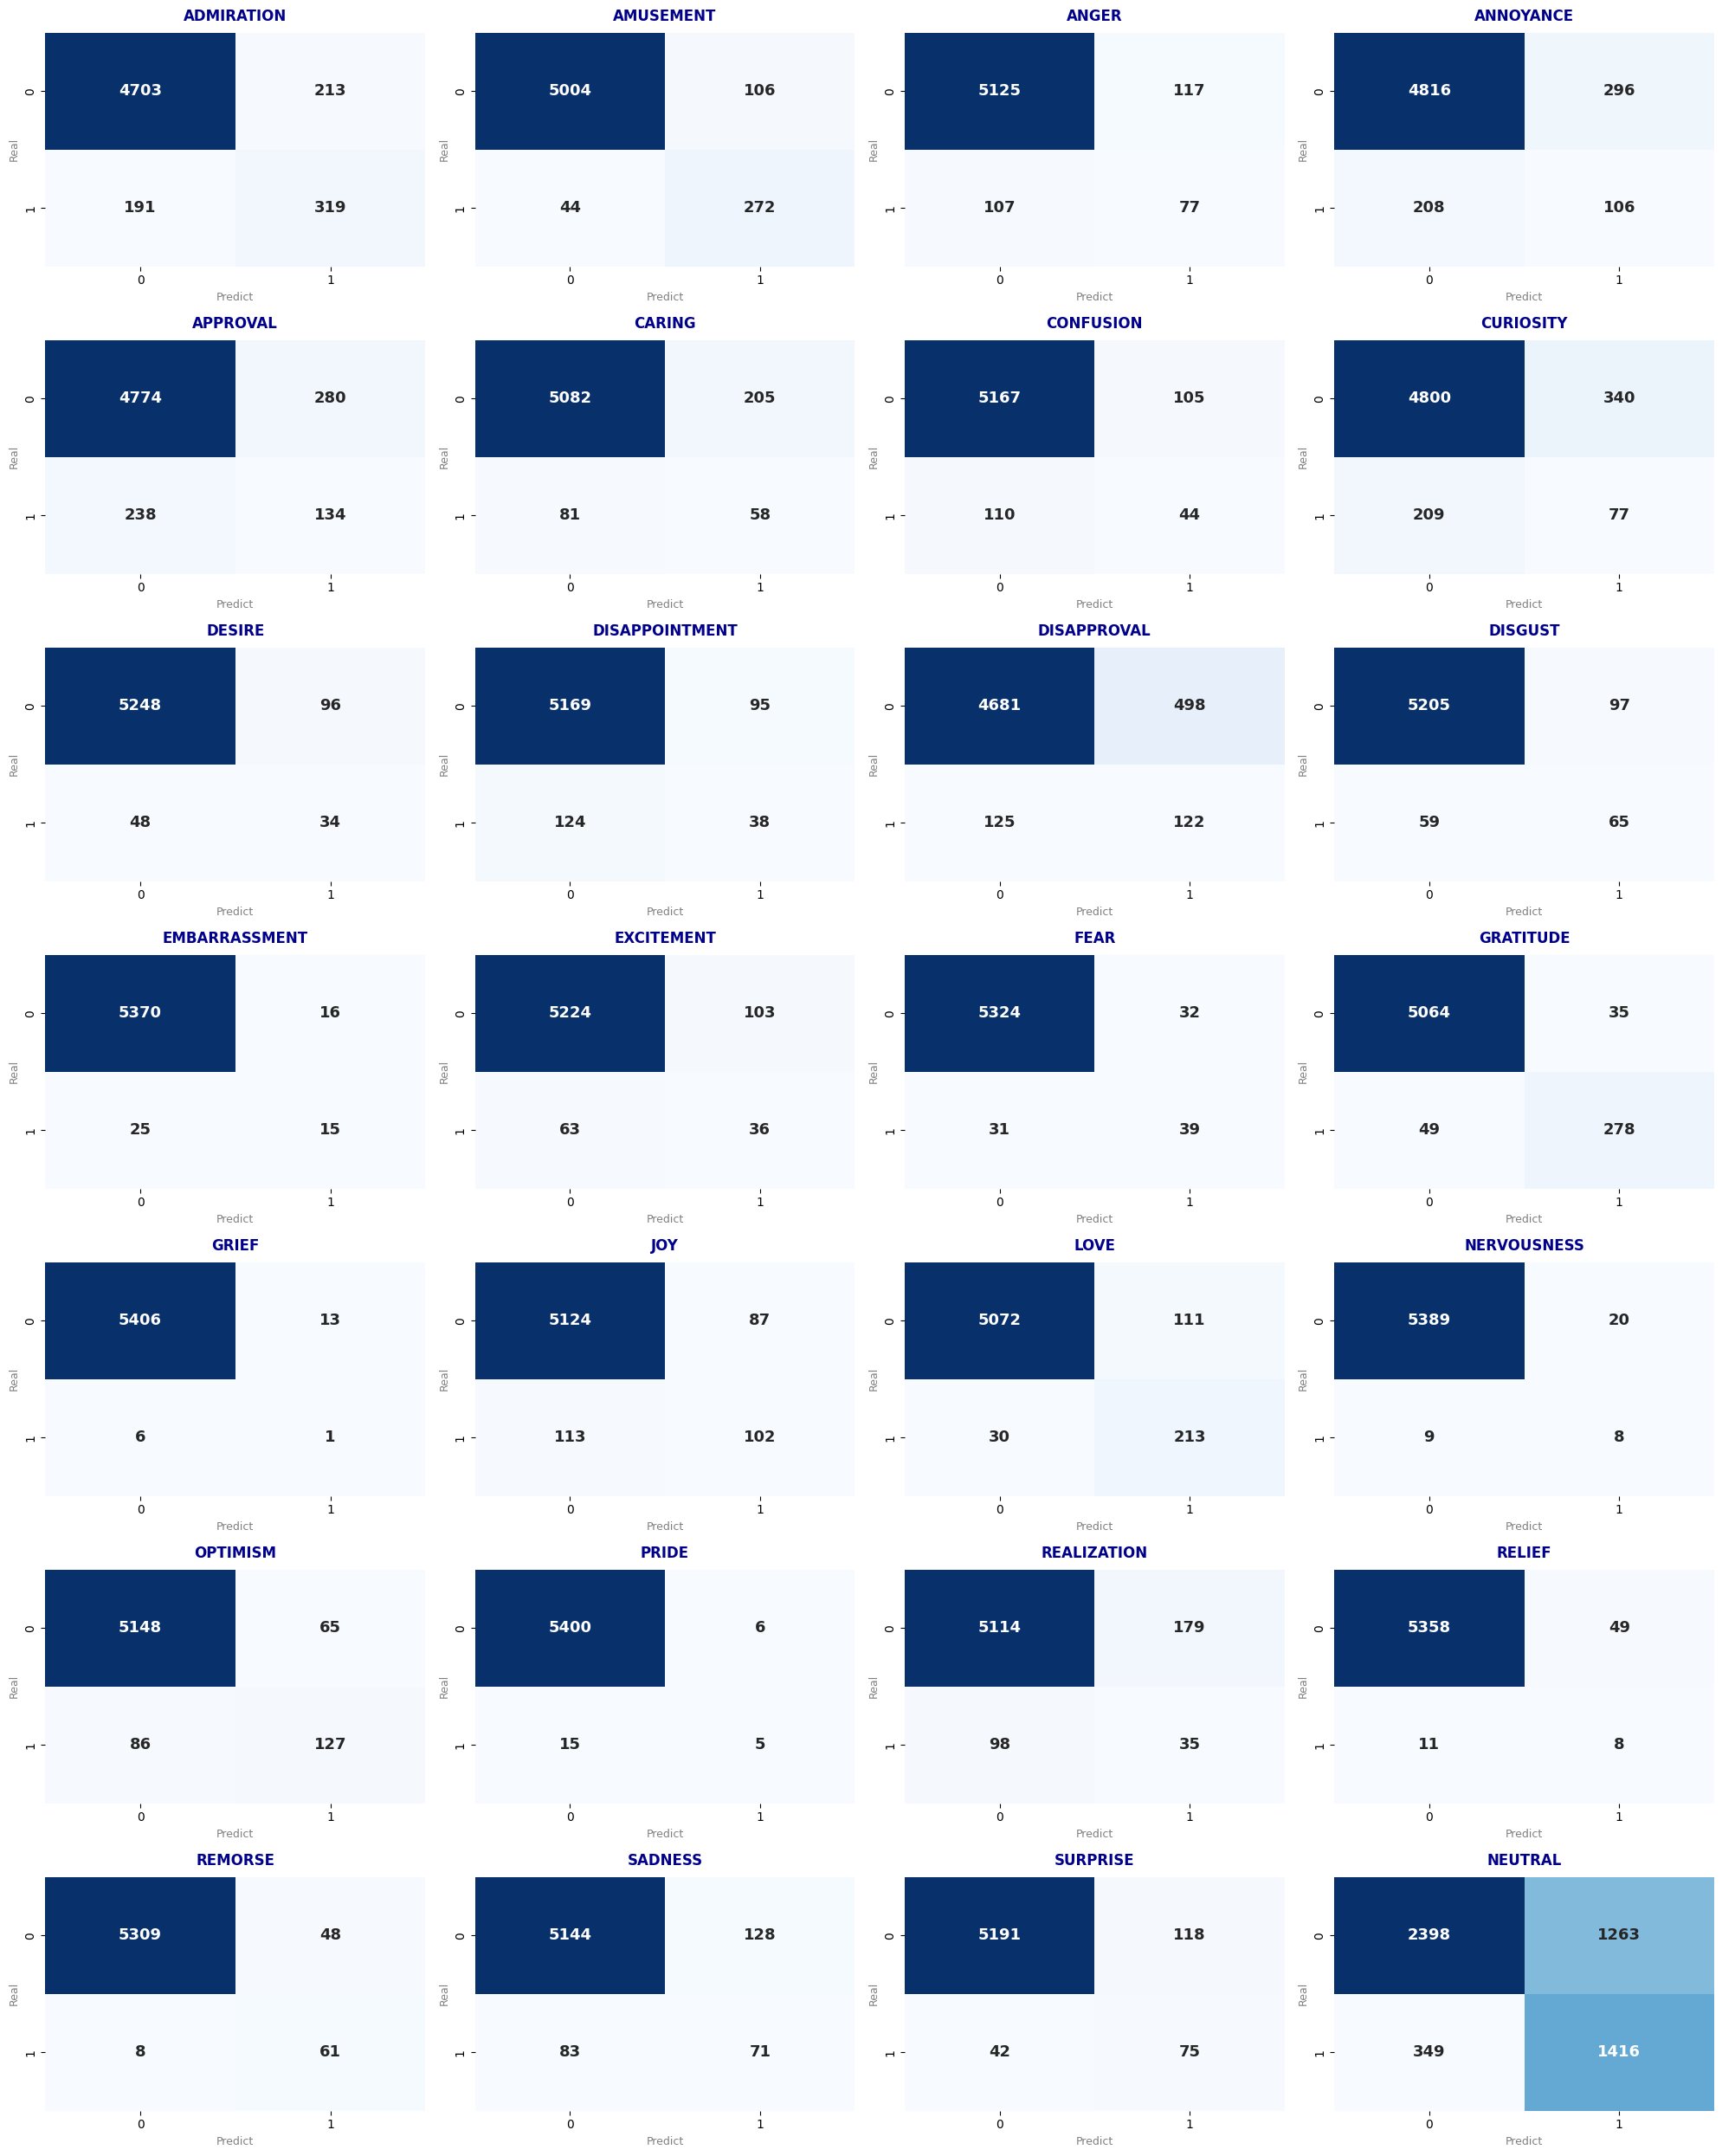

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

mcm = multilabel_confusion_matrix(Y_test, Y_pred_test)

fig, axes = plt.subplots(7, 4, figsize=(20, 25))
axes = axes.ravel()

for idx, label in enumerate(emotion_labels):
    ax = axes[idx]
    sns.heatmap(mcm[idx], annot=True, fmt='d', cmap='Blues', cbar=False,
                #xticklabels=['Đoán KHÔNG', 'Đoán CÓ'],
                #yticklabels=['Gốc KHÔNG', 'Gốc CÓ'],
                ax=ax,
                annot_kws={"size": 13, "weight": "bold"})

    ax.set_title(f"{label.upper()}", fontsize=12, fontweight='bold', color='darkblue', pad=10)
    ax.set_xlabel("Predict", fontsize=9, color='gray')
    ax.set_ylabel("Real", fontsize=9, color='gray')

plt.tight_layout()
plt.show()

**Live test (nhập text và dự đoán)**

In [10]:
import numpy as np

print("Nhập một câu tiếng Anh bất kỳ để xem mô hình tính Khoảng cách ranh giới (LinearSVC).")
print("Gõ 'exit', 'thoat' để dừng chương trình.\n")

while True:
    user_input = input("✍️ Nhập bình luận tiếng Anh: ")

    if user_input.lower() in ['thoát', 'thoat', 'exit', 'quit']:
        print("👋 Đã đóng cổng thực nghiệm thành công!")
        break

    if user_input.strip() == "":
        continue

    # 1. Làm sạch văn bản và chuyển hóa TF-IDF
    cleaned_input = advanced_clean_text(user_input)
    input_tfidf = tfidf.transform([cleaned_input])

    # Gọi decision_function từ từng lõi SVM bên trong và gom lại thành danh sách 28 khoảng cách Z
    distances_list = [estimator.decision_function(input_tfidf)[0] for estimator in ovr_classifier.estimators_]

    print(f'\n📝 Câu gốc nhập vào : "{user_input}"')
    print(f'✨ Sau khi làm sạch  : "{cleaned_input}"')
    print("🤖 KHOẢNG CÁCH ĐẾN ĐƯỜNG RANH GIỚI CỦA 28 MÔ HÌNH SVM:")

    activated_any = False

    # 3. Duyệt qua 28 nhãn để đối chiếu với đường ranh giới
    for idx, distance in enumerate(distances_list):

        # Mặc định của SVM: Khoảng cách > 0.0 là thuộc lớp đó, < 0.0 là không thuộc.
        if distance > 0.0:
            print(f"   - [KÍCH HOẠT] {emotion_labels[idx].upper()}: Z = {distance:.4f}")
            activated_any = True

    # 4. Cơ chế cứu trợ nếu câu quá khó, khoảng cách của mọi nhãn đều bị ÂM (< 0.0)
    if not activated_any:
        top_idx = np.argmax(distances_list)
        top_distance = distances_list[top_idx]

        # Nới lỏng ranh giới cứu trợ một chút: Dù bị âm nhẹ (>-0.5) nhưng cao nhất thì vẫn gợi ý
        if top_distance > -0.5:
            print(f"   - {emotion_labels[top_idx].upper()}: Z = {top_distance:.4f} (Sắc thái tiềm năng nhất)")
        else:
            print(f"   - NEUTRAL: Z = {top_distance:.4f} (Khoảng cách âm quá sâu, hoàn toàn trung tính)")
    print("-" * 60)

Nhập một câu tiếng Anh bất kỳ để xem mô hình tính Khoảng cách ranh giới (LinearSVC).
Gõ 'exit', 'thoat' để dừng chương trình.

✍️ Nhập bình luận tiếng Anh: "Good luck with your final exam tomorrow, you'll do great!"

📝 Câu gốc nhập vào : ""Good luck with your final exam tomorrow, you'll do great!""
✨ Sau khi làm sạch  : "good luck with your final exam tomorrow you will do great!"
🤖 KHOẢNG CÁCH ĐẾN ĐƯỜNG RANH GIỚI CỦA 28 MÔ HÌNH SVM:
   - [KÍCH HOẠT] ADMIRATION: Z = 0.9357
   - [KÍCH HOẠT] CARING: Z = 0.2504
   - [KÍCH HOẠT] GRATITUDE: Z = 0.2421
   - [KÍCH HOẠT] OPTIMISM: Z = 0.8533
------------------------------------------------------------
✍️ Nhập bình luận tiếng Anh: I laughed so hard at this that my ribs actually hurt.

📝 Câu gốc nhập vào : "I laughed so hard at this that my ribs actually hurt."
✨ Sau khi làm sạch  : "i laugh so hard at this that my rib actually hurt"
🤖 KHOẢNG CÁCH ĐẾN ĐƯỜNG RANH GIỚI CỦA 28 MÔ HÌNH SVM:
   - [KÍCH HOẠT] AMUSEMENT: Z = 0.4280
   - [KÍCH HOẠT] DISA

In [11]:
# =====================================================================
# HÀM MỔ XẺ TRỌNG SỐ: SVM NGUYÊN BẢN (KHÔNG DÙNG XÁC SUẤT)
# =====================================================================
def mose_svm(text, vectorizer, model, class_labels, best_thresholds):
    print(f"=== ĐANG MỔ XẺ CÂU: '{text}' (SVM NGUYÊN BẢN) ===\n")

    vec = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()
    nonzero_indices = vec.nonzero()[1]
    FIXED_THRESHOLD = 0.0

    for i, label in enumerate(class_labels):
        svm_core = model.estimators_[i]
        b0 = svm_core.intercept_[0]
        weights = svm_core.coef_[0]

        print(f"► MÔ HÌNH NHÃN: [{label.upper()}]")
        print(f"   - Hệ số nền (Bias b0 - khoảng cách gốc): {b0:.4f}")

        distance_z = b0
        for idx in nonzero_indices:
            w = weights[idx]
            x_val = vec[0, idx]
            contribution = w * x_val
            distance_z += contribution

            # In chi tiết trọng số của từng từ để mổ xẻ
            print(f"      + Từ '{feature_names[idx]:>10}': Trọng số w = {w:>7.4f} --> Đóng góp = {contribution:>7.4f}")

        print(f"   => Khoảng cách hình học tổng (Distance Z): {distance_z:.4f}")
        print(f"   => Ngưỡng khoảng cách (Biên giới): {FIXED_THRESHOLD:.1f}")
        print(f"   => Kết luận: {'[CÓ NHÃN NÀY]' if distance_z >= FIXED_THRESHOLD else '[KHÔNG CÓ]'}")
        print("*" * 60 + "\n")

cau_van_test = "I am so excited"
mose_svm(cau_van_test, tfidf, ovr_classifier, emotion_labels, best_thresholds)

=== ĐANG MỔ XẺ CÂU: 'I am so excited' (SVM NGUYÊN BẢN) ===

► MÔ HÌNH NHÃN: [ADMIRATION]
   - Hệ số nền (Bias b0 - khoảng cách gốc): -0.3401
      + Từ '   excited': Trọng số w = -0.0420 --> Đóng góp = -0.0420
   => Khoảng cách hình học tổng (Distance Z): -0.3822
   => Ngưỡng khoảng cách (Biên giới): 0.0
   => Kết luận: [KHÔNG CÓ]
************************************************************

► MÔ HÌNH NHÃN: [AMUSEMENT]
   - Hệ số nền (Bias b0 - khoảng cách gốc): -0.6285
      + Từ '   excited': Trọng số w = -0.0218 --> Đóng góp = -0.0218
   => Khoảng cách hình học tổng (Distance Z): -0.6503
   => Ngưỡng khoảng cách (Biên giới): 0.0
   => Kết luận: [KHÔNG CÓ]
************************************************************

► MÔ HÌNH NHÃN: [ANGER]
   - Hệ số nền (Bias b0 - khoảng cách gốc): -0.2910
      + Từ '   excited': Trọng số w = -0.0397 --> Đóng góp = -0.0397
   => Khoảng cách hình học tổng (Distance Z): -0.3308
   => Ngưỡng khoảng cách (Biên giới): 0.0
   => Kết luận: [KHÔNG CÓ]
***

**Xuất file pkl**

In [12]:
import joblib
from google.colab import files

# Lưu mô hình bằng đúng tên biến ovr_classifier của bạn
joblib.dump(ovr_classifier, 'svm_model.pkl')

print("✅ Đã lưu xong SVM! Đang tự động tải về...")
files.download('svm_model.pkl')

✅ Đã lưu xong SVM! Đang tự động tải về...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>